MPL Data Preparation

In [201]:
# ----------------------- Import required libraries ---------------
import numpy as np
from sklearn.model_selection import train_test_split
import torch
import torch.nn as nn
import time
import random
import matplotlib.pyplot as plt

In [202]:
# ============================
# Fix random seeds
# ============================

seed = 42

torch.manual_seed(seed)
np.random.seed(seed)
random.seed(seed)

if torch.cuda.is_available():
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

In [203]:
# ----------------------- Load dataset ----------------------

# Data address to run on localhost
# data = np.loadtxt('../data/MLoGPU_data3_train.csv', delimiter=',')

# Data address to run on Google Colab
data = np.loadtxt('/content/MLoGPU_data3_train.csv', delimiter=',')

X = data[..., :-1]
y = data[..., -1]

# Fix labels (make them 0-based)
y = y - 1

print(X.shape, y.shape)

(4000, 7) (4000,)


In [204]:
# ----------------------- Train / Test split -----------------------

# Use EXACT same split settings as teammate
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

# Verify shapes
print("Train shape:", X_train.shape, y_train.shape)
print("Test shape:", X_test.shape, y_test.shape)

Train shape: (3000, 7) (3000,)
Test shape: (1000, 7) (1000,)


In [205]:
# ----------------------- Data normalization -----------------------

# Compute mean and std ONLY from training data
mean_train = np.mean(X_train, axis=0)
std_train = np.std(X_train, axis=0)

# Avoid division by zero
std_train[std_train == 0] = 1

# Normalize data
X_train_norm = (X_train - mean_train) / std_train
X_test_norm = (X_test - mean_train) / std_train

# Check results
print("Train mean (approx):", np.mean(X_train_norm, axis=0))
print("Train std (approx):", np.std(X_train_norm, axis=0))

Train mean (approx): [ 2.08721929e-17  3.15895458e-16 -1.23604830e-17 -1.59344760e-16
 -2.01135405e-17  4.45569507e-17  3.59305178e-16]
Train std (approx): [1. 1. 1. 1. 1. 1. 1.]


Staaaaaaaart MPL Implementation

In [206]:
# ============================
# Select device (CPU or GPU)
# ============================

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Using device:", device)

Using device: cuda


In [207]:
# ============================
# Convert data to PyTorch tensors
# ============================

# Features → float32 (VERY important for neural networks)
X_train_tensor = torch.tensor(X_train_norm, dtype=torch.float32)
X_test_tensor  = torch.tensor(X_test_norm, dtype=torch.float32)

# Labels → long (required for classification with CrossEntropyLoss)
y_train_tensor = torch.tensor(y_train, dtype=torch.long)
y_test_tensor  = torch.tensor(y_test, dtype=torch.long)

# Print shapes
print("X_train_tensor:", X_train_tensor.shape)
print("y_train_tensor:", y_train_tensor.shape)

X_train_tensor: torch.Size([3000, 7])
y_train_tensor: torch.Size([3000])


In [208]:
# ============================
# Set hyperparameters
# Note: You can experiment with these values to see how they affect training!
# Also, results of some different hyperparameter settings are at the end of this notebook.
# hidden_size = 32 and learning_rate = 0.01 gave the highest accuracy
# ============================
hidden_size = 32
learning_rate = 0.01

In [209]:
# ============================
# Define MLP model
# ============================
class MLP(nn.Module):
    def __init__(self, hidden_sizeOK):
        super(MLP, self).__init__()

        # Input layer → hidden layer
        self.fc1 = nn.Linear(7, hidden_size)

        # Activation
        self.relu = nn.ReLU()

        # Hidden → output layer (7 classes)
        self.fc2 = nn.Linear(hidden_size, 7)

    def forward(self, x):
        x = self.fc1(x)     # Linear transformation
        x = self.relu(x)    # Non-linearity
        x = self.fc2(x)     # Output layer
        return x

In [210]:
# ============================
# CPU RUN
# ============================

device_cpu = torch.device("cpu")

# Move data to CPU
X_train_cpu = X_train_tensor.to(device_cpu)
X_test_cpu  = X_test_tensor.to(device_cpu)
y_train_cpu = y_train_tensor.to(device_cpu)
y_test_cpu  = y_test_tensor.to(device_cpu)

# Create fresh CPU model
model_cpu = MLP(hidden_size).to(device_cpu)

criterion = nn.CrossEntropyLoss()
optimizer_cpu = torch.optim.Adam(model_cpu.parameters(), lr=learning_rate)

In [211]:
# ============================
# Training loop
# ============================

# Number of epochs (you can increase later)
num_epochs = 50

# Store loss values (optional, useful for plotting)
loss_history = []

for epoch in range(num_epochs):

    # Set model to training mode
    model_cpu.train()

    # Forward pass: compute predictions
    outputs = model_cpu(X_train_cpu)

    # Compute loss
    loss = criterion(outputs, y_train_cpu)

    # Backward pass: compute gradients
    optimizer_cpu.zero_grad()   # Clear old gradients
    loss.backward()         # Compute new gradients

    # Update weights
    optimizer_cpu.step()

    # Save loss
    loss_history.append(loss.item())

    # Print progress every 10 epochs
    if (epoch + 1) % 10 == 0:
        print(f"Epoch [{epoch+1}/{num_epochs}], Loss: {loss.item():.4f}")

Epoch [10/50], Loss: 1.4426
Epoch [20/50], Loss: 1.2180
Epoch [30/50], Loss: 1.1626
Epoch [40/50], Loss: 1.1263
Epoch [50/50], Loss: 1.1080


In [212]:
# ============================
# Evaluation (accuracy)
# ============================

# Set model to evaluation mode
model_cpu.eval()

# Disable gradient computation (faster)
with torch.no_grad():

    # Forward pass
    outputs = model_cpu(X_test_cpu)

    # Get predicted class (max score)
    _, predicted = torch.max(outputs, dim=1)

    # Compute accuracy
    correct = (predicted == y_test_cpu).sum().item()

    total = y_test_cpu.size(0)

    accuracy = 100 * correct / total

print(f"Test Accuracy: {accuracy:.2f}%")

Test Accuracy: 53.60%


In [213]:
# ============================
# Measure training time (CPU)
# ============================
start_time = time.time()

# ---- Training loop (same as before) ----
num_epochs = 50

for epoch in range(num_epochs):
    model_cpu.train()

    outputs = model_cpu(X_train_cpu)
    loss = criterion(outputs, y_train_cpu)

    optimizer_cpu.zero_grad()
    loss.backward()
    optimizer_cpu.step()

end_time = time.time()

train_time = end_time - start_time

print(f"Training time (CPU): {train_time:.4f} seconds")

Training time (CPU): 0.1112 seconds


In [214]:
# ============================
# Measure inference time (CPU)
# ============================

model_cpu.eval()

start_time = time.time()

with torch.no_grad():
    outputs = model_cpu(X_test_cpu)
    _, predicted = torch.max(outputs, dim=1)

end_time = time.time()

inference_time = end_time - start_time

print(f"Inference time (CPU): {inference_time:.6f} seconds")

Inference time (CPU): 0.000577 seconds


Start test on GPU

In [215]:
# ============================
# Check GPU availability
# ============================
print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU name:", torch.cuda.get_device_name(0))

CUDA available: True
GPU name: Tesla T4


In [216]:
# ============================
# Select device
# ============================

device_gpu = torch.device("cuda")

X_train_gpu = X_train_tensor.to(device_gpu)
X_test_gpu  = X_test_tensor.to(device_gpu)
y_train_gpu = y_train_tensor.to(device_gpu)
y_test_gpu  = y_test_tensor.to(device_gpu)

In [217]:
# ============================
# Create fresh model on device
# ============================

model_gpu = MLP(hidden_size).to(device_gpu)

criterion = nn.CrossEntropyLoss()
optimizer_gpu = torch.optim.Adam(model_gpu.parameters(), lr=learning_rate)

print(next(model_gpu.parameters()).device)

cuda:0


In [218]:
# ============================
# Measure training time (GPU)
# ============================

num_epochs = 50
loss_history = []

# Synchronize before timing
if device_gpu.type == "cuda":
    torch.cuda.synchronize()

start_time = time.time()

for epoch in range(num_epochs):
    model_gpu.train()

    outputs = model_gpu(X_train_gpu)
    loss = criterion(outputs, y_train_gpu)

    optimizer_gpu.zero_grad()
    loss.backward()
    optimizer_gpu.step()

    loss_history.append(loss.item())

    if (epoch + 1) % 10 == 0:
        print(f"Epoch [{epoch+1}/{num_epochs}], Loss: {loss.item():.4f}")

# Synchronize after training
if device_gpu.type == "cuda":
    torch.cuda.synchronize()

end_time = time.time()
train_time_gpu = end_time - start_time

print(f"Training time (GPU): {train_time_gpu:.4f} seconds")

Epoch [10/50], Loss: 1.3311
Epoch [20/50], Loss: 1.1899
Epoch [30/50], Loss: 1.1394
Epoch [40/50], Loss: 1.1099
Epoch [50/50], Loss: 1.0931
Training time (GPU): 0.0673 seconds


In [219]:
# ============================
# Measure inference time (GPU)
# ============================

model_gpu.eval()

if device_gpu.type == "cuda":
    torch.cuda.synchronize()

start_time = time.time()

with torch.no_grad():
    outputs = model_gpu(X_test_gpu)
    _, predicted = torch.max(outputs, dim=1)

if device_gpu.type == "cuda":
    torch.cuda.synchronize()

end_time = time.time()
inference_time_gpu = end_time - start_time

print(f"Inference time (GPU): {inference_time_gpu:.6f} seconds")

Inference time (GPU): 0.001166 seconds


In [220]:
# ============================
# Evaluate accuracy on GPU
# ============================

model_gpu.eval()

with torch.no_grad():
    outputs = model_gpu(X_test_gpu)
    _, predicted = torch.max(outputs, dim=1)

    correct = (predicted == y_test_gpu).sum().item()
    total = y_test_gpu.size(0)

accuracy_gpu = 100 * correct / total

print(f"Test Accuracy (GPU): {accuracy_gpu:.2f}%")

Test Accuracy (GPU): 56.20%


In [221]:
# ============================
# Compare CPU and GPU results
# ============================

print(f"CPU training time:   {train_time:.4f} s")
print(f"GPU training time:   {train_time_gpu:.4f} s")
print(f"CPU inference time:  {inference_time:.6f} s")
print(f"GPU inference time:  {inference_time_gpu:.6f} s")
print(f"CPU accuracy:        {accuracy:.2f}%")
print(f"GPU accuracy:        {accuracy_gpu:.2f}%")

CPU training time:   0.1112 s
GPU training time:   0.0673 s
CPU inference time:  0.000577 s
GPU inference time:  0.001166 s
CPU accuracy:        53.60%
GPU accuracy:        56.20%


# Experiments and Improvements

In this section, we evaluate the effect of different hyperparameters on the performance of the MLP model. We focus on two main factors:
- Hidden layer size
- Learning rate

The baseline configuration uses:
- Hidden size = 32
- Learning rate = 0.001

---

## Results

| Experiment | Hidden Size | Learning Rate | CPU Accuracy (%) | GPU Accuracy (%) | CPU Train Time (s) | GPU Train Time (s) |
|------------|------------|---------------|------------------|------------------|--------------------|--------------------|
| Baseline   | 32         | 0.001         | ~44.0            | ~47.1            | ~0.10              | ~0.08              |
| Exp 1      | 16         | 0.001         | 40.90            | 42.80            | 0.1433             | 0.0926             |
| Exp 2      | 64         | 0.001         | 51.80            | 47.90            | 0.1367             | 0.0694             |
| Exp 3 ⭐    | 32         | 0.01          | 53.60            | **56.20**        | 0.1166             | 0.0757             |
| Exp 4      | 32         | 0.0005        | 34.30            | 40.80            | 0.1164             | 0.0703             |

---

## Analysis

- **Hidden Size Effect:**  
  Increasing the hidden size from 16 to 64 improves model capacity and leads to better accuracy. However, the improvement is moderate, indicating diminishing returns for larger models.

- **Learning Rate Effect:**  
  The learning rate has a significant impact on performance:
  - A higher learning rate (0.01) results in faster convergence and the best accuracy.
  - A very small learning rate (0.0005) slows down learning and reduces accuracy.

- **Best Configuration:**  
  The best result was achieved with:
  - Hidden size = 32  
  - Learning rate = 0.01  

- **CPU vs GPU Performance:**  
  GPU performance varies depending on the workload. For this relatively small model and dataset, GPU does not always provide a significant speedup due to overhead. However, for larger configurations, GPU tends to perform better.

---

## Conclusion

The experiments show that model performance is sensitive to hyperparameter choices. Proper tuning of hidden size and learning rate can significantly improve accuracy. The results also demonstrate that GPU acceleration is more beneficial for larger computational workloads.

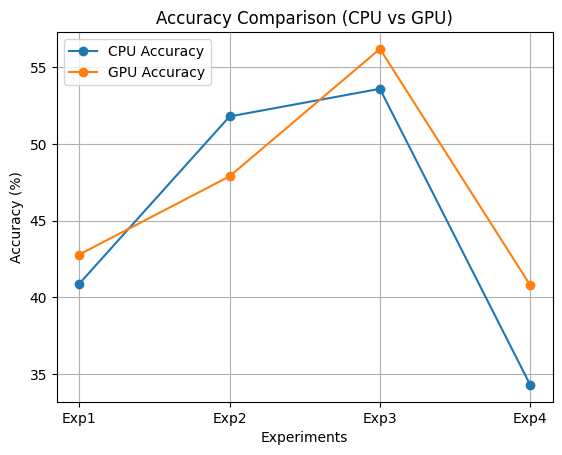

In [222]:
# ----------------------- These values are based on different hyperparameters values -----------------------
# Experiment labels
experiments = ["Exp1", "Exp2", "Exp3", "Exp4"]

# Your results
cpu_acc = [40.90, 51.80, 53.60, 34.30]
gpu_acc = [42.80, 47.90, 56.20, 40.80]

# Plot
plt.figure()

plt.plot(experiments, cpu_acc, marker='o', label='CPU Accuracy')
plt.plot(experiments, gpu_acc, marker='o', label='GPU Accuracy')

# Labels and title
plt.xlabel("Experiments")
plt.ylabel("Accuracy (%)")
plt.title("Accuracy Comparison (CPU vs GPU)")

# Legend
plt.legend()

# Grid for better readability
plt.grid()

plt.show()